In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets 
  
# metadata 
# print(car_evaluation.metadata) 
  
# variable information 
# print(car_evaluation.variables) 

df = pd.concat([X, y], axis=1)
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


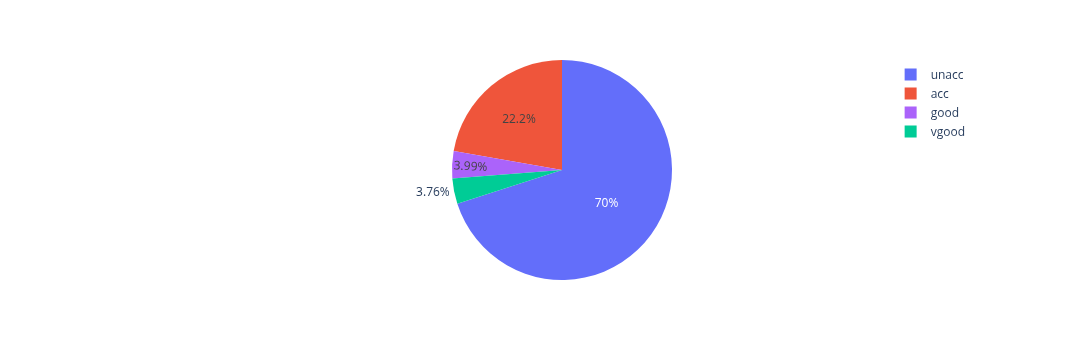

In [3]:
fig = px.pie(df, names='class', color='class')
fig.show()

['low' 'med' 'high']
0 low
['2' '3' '4' '5more']
[2, 3, 4] [144, 144, 144]
1 med
['2' '3' '4' '5more']
[2, 3, 4] [144, 144, 144]
2 high
['2' '3' '4' '5more']
[2, 3, 4] [144, 144, 144]


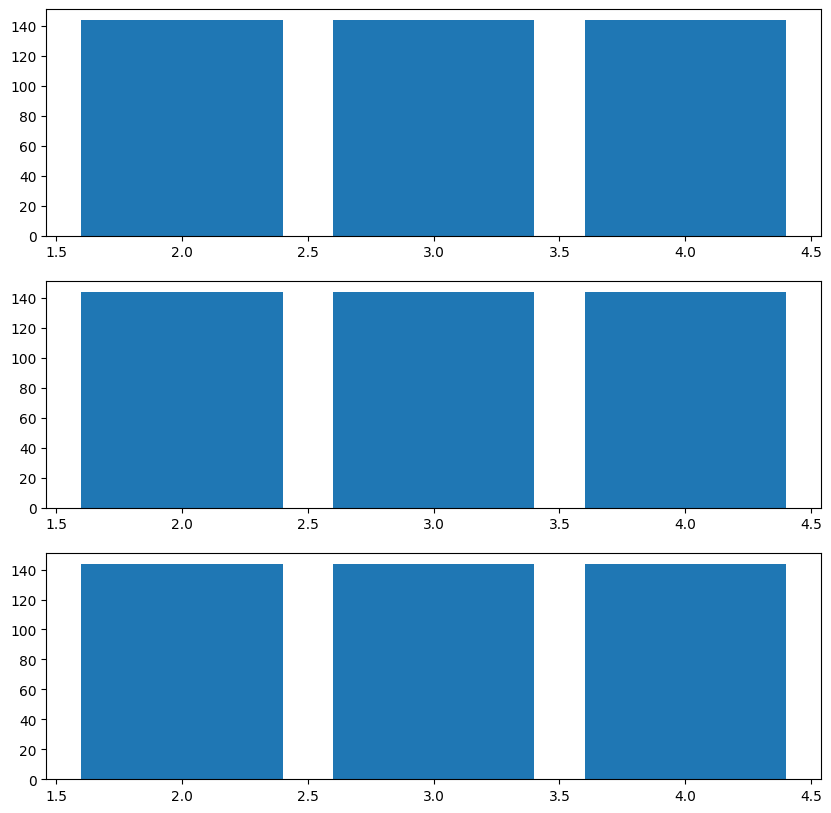

In [4]:
def plot_safety_bars():    
    safety_values = X['safety'].unique()
    print(safety_values)

    fig, axes = plt.subplots(3, 1, figsize=(10,10))

    for i, safety in enumerate(safety_values):
        print(i, safety)
        Xs = X[X['safety'] == safety]
        xs = []
        ys = []
        print(Xs['doors'].unique())
        for doors in [2, 3, 4]:
            xs.append(doors)
            ys.append(len(Xs[Xs['doors'] == str(doors)]))
        print(xs, ys)
        axes[i].bar(xs, ys)
    plt.show()
plot_safety_bars()
        

In [5]:
mapping = {
    'vhigh': 4, 'high': 3, 'med': 2, 'low': 1,
    'small': 1, '5more': 5, 'more': 5, 'big': 3, '2': 2, '3': 3, '4': 4
}

df2 = df.replace(mapping)
df2.head()

/tmp/ipykernel_11706/2500101674.py:6: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,buying,maint,doors,persons,lug_boot,safety,class
0,4,4,2,2,1,1,unacc
1,4,4,2,2,1,2,unacc
2,4,4,2,2,1,3,unacc
3,4,4,2,2,2,1,unacc
4,4,4,2,2,2,2,unacc


In [6]:
attr = ['buying', 'maint', 'doors', 'lug_boot', 'safety']

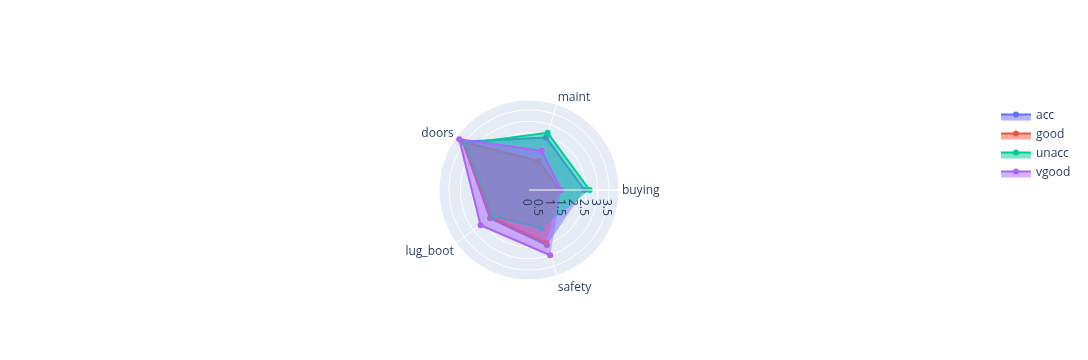

In [7]:
gg = df2.groupby('class')[attr].mean()

fig = go.Figure()

for car_class in gg.index:
    values = gg.loc[car_class].tolist()

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=attr + [attr[0]],
        fill='toself',
        name=car_class
    ))

fig.show()

In [17]:
df['heuristic_yes'] = (
    (df['safety'] == 'high') &
    (df2['maint'] < 2)
)

df['correct'] = (df['class'].isin(['good', 'vgood']) == df['heuristic_yes'])

In [18]:
print(f'Accuracy: {df['correct'].mean()}')

Accuracy: 0.9224537037037037


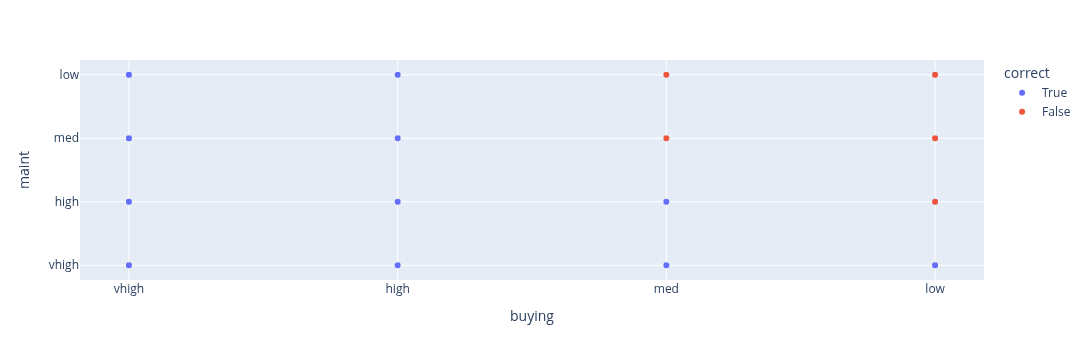

In [23]:
fig = px.scatter(df, x='buying', y='maint', color='correct')
fig.show()